In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('Super_Store.csv',encoding='latin1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
3,6,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694
4,11,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-TA-10001539,Furniture,Tables,Chromcraft Rectangular Conference Tables,1706.1840,9,0.20,85.3092


In [4]:
df = df[['Order Date','Sales']]
df.head()

,Order Date,Sales
0,11/8/2016,261.9600
1,11/8/2016,731.9400
2,10/11/2015,957.5775
3,6/9/2014,48.8600
4,6/9/2014,1706.1840


In [5]:
df.dtypes

Order Date     object
Sales         float64
dtype: object

In [7]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [8]:
df.head(10)

,Order Date,Sales
0,2016-11-08,261.9600
1,2016-11-08,731.9400
2,2015-10-11,957.5775
3,2014-06-09,48.8600
4,2014-06-09,1706.1840
5,2017-07-16,71.3720
6,2015-09-25,1044.6300
7,2015-09-17,3083.4300
8,2015-09-17,124.2000
9,2016-12-08,190.9200


In [11]:
w1 = df.groupby(['Order Date'])['Sales'].sum().reset_index()
w1

,Order Date,Sales
0,2014-01-06,2573.8200
1,2014-01-07,76.7280
2,2014-01-10,51.9400
3,2014-01-11,9.9400
4,2014-01-13,879.9390
...,...,...
884,2017-12-24,1393.4940
885,2017-12-25,832.4540
886,2017-12-28,551.2568
887,2017-12-29,2330.7180


In [12]:
w1 = w1.sort_values('Order Date')
w1.head(25)

,Order Date,Sales
0,2014-01-06,2573.820
1,2014-01-07,76.728
2,2014-01-10,51.940
3,2014-01-11,9.940
4,2014-01-13,879.939
5,2014-01-14,61.960
6,2014-01-16,127.104
7,2014-01-19,181.470
8,2014-01-20,1413.510
9,2014-01-21,25.248


In [13]:
#### Date should be set as index for Resampling

In [14]:
w1 = w1.set_index('Order Date')
w1

,Sales
Order Date,
2014-01-06,2573.8200
2014-01-07,76.7280
2014-01-10,51.9400
2014-01-11,9.9400
2014-01-13,879.9390
...,...
2017-12-24,1393.4940
2017-12-25,832.4540
2017-12-28,551.2568


In [15]:
w1.shape

(889, 1)

#### Resampling (days to month)

In [19]:
df1 = w1.resample('MS').mean()  # MS = Month Start
df1.head(20)

,Sales
Order Date,
2014-01-01,480.194231
2014-02-01,367.931600
2014-03-01,857.291529
2014-04-01,567.488357
2014-05-01,432.049188
2014-06-01,695.059242
2014-07-01,601.169500
2014-08-01,457.521656
2014-09-01,992.353367


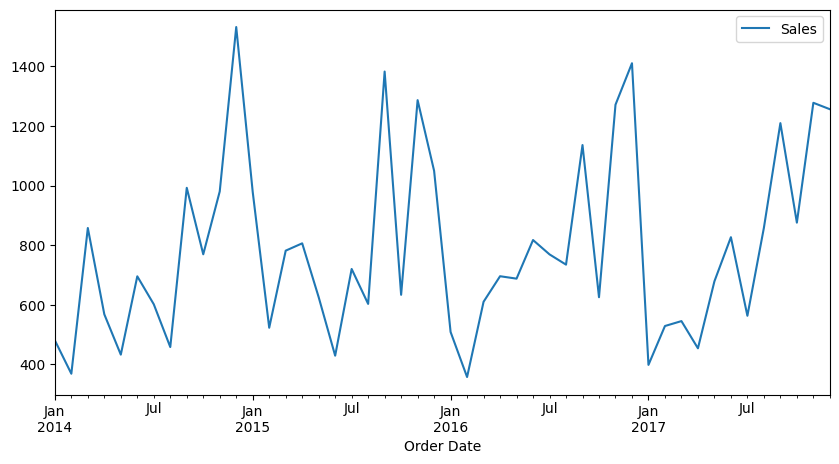

In [21]:
df1.plot(kind='line',figsize=(10,5))
plt.show()

In [26]:
from statsmodels.tsa.seasonal import seasonal_decompose

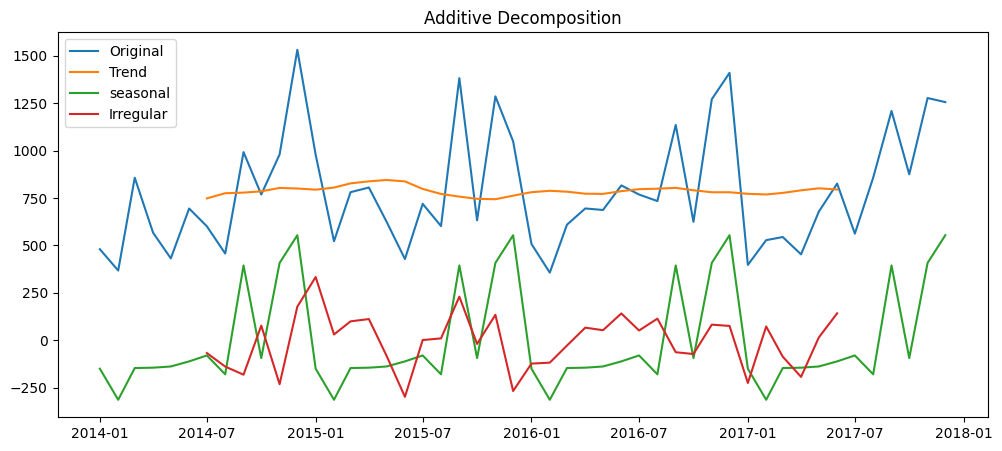

In [28]:
# Additive Decomposition: Y(T) = Trend + Seasonal + Irr
decom = seasonal_decompose(df1, model='add')

org = decom.observed       # Original data
trend = decom.trend        # Trend component
seasonal = decom.seasonal  # Seasonal component
irr = decom.resid          # Irregular Component

plt.figure(figsize=(12,5))
plt.plot(org,label='Original')
plt.plot(trend,label='Trend')
plt.plot(seasonal,label='seasonal')
plt.plot(irr,label='Irregular')
plt.title('Additive Decomposition') 
plt.legend()
plt.show()

In [29]:
seasonal_df = pd.DataFrame({'Original':org,'Trend':trend,
                            'Seasonal':seasonal,'Irr':irr})
seasonal_df.head(20)

,Original,Trend,Seasonal,Irr
Order Date,,,,
2014-01-01,480.194231,NaN,-149.858992,NaN
2014-02-01,367.931600,NaN,-313.772729,NaN
2014-03-01,857.291529,NaN,-146.335750,NaN
2014-04-01,567.488357,NaN,-144.492328,NaN
2014-05-01,432.049188,NaN,-138.079245,NaN
2014-06-01,695.059242,NaN,-111.255103,NaN
2014-07-01,601.169500,748.471753,-79.957342,-67.344911
2014-08-01,457.521656,775.663349,-179.492825,-138.648868
2014-09-01,992.353367,778.930390,394.908764,-181.485787


In [23]:
from statsmodels.tsa.stattools import adfuller

In [24]:
def adf_test(data):
    res = adfuller(data)
    print('Test_stat',res[0])
    print('p',res[1])
    alpha = 0.05
    if res[1] > alpha :
        print('Ho accepted => Data is not stationary')
    else:
        print('H1 accepted => Data is stationary')

In [25]:
adf_test(df1)  # d = 0

Test_stat -5.191070187339278
p 9.168756655665362e-06
H1 accepted => Data is stationary


In [ ]:
#### Exponential Smoothing
####    ARIMA
####    SARIMA